# Visualization: Lower Bound for VC-Dimension of Balls in $\mathbb{R}^n$

This notebook visualizes the lower bound construction in the proof that the VC-dimension of balls in $\mathbb{R}^n$ is at least $n+1$.

We use the vertices of a regular $n$-simplex in $\mathbb{R}^n$ (for visualization, $n=2$ or $n=3$), and show how, for any subset $S$ of these points, there exists a ball containing exactly the points in $S$. This demonstrates that the set is shattered by balls, establishing the lower bound.

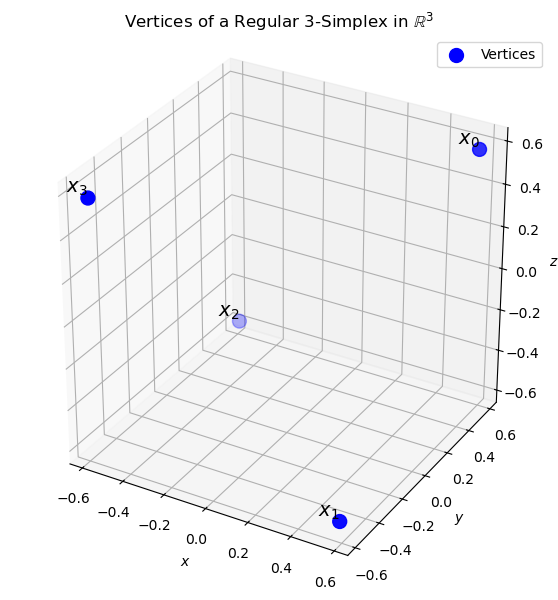

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations, chain

# Helper to generate vertices of a regular n-simplex centered at the origin
# For n=2: equilateral triangle, for n=3: regular tetrahedron

def regular_simplex(n):
    if n == 2:
        # Equilateral triangle
        angles = np.linspace(0, 2 * np.pi, 4)[:-1]
        return np.stack([np.cos(angles), np.sin(angles)], axis=1)
    elif n == 3:
        # Regular tetrahedron
        a = 1.0
        points = np.array([
            [1, 1, 1],
            [1, -1, -1],
            [-1, 1, -1],
            [-1, -1, 1]
        ])
        return points / np.linalg.norm(points[0])
    else:
        raise NotImplementedError("Only n=2 or n=3 supported for visualization.")

# Choose n=3 for 3D visualization
n = 3
vertices = regular_simplex(n)

# Plot the simplex vertices in 3D
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color='blue', s=100, label='Vertices')
for i, v in enumerate(vertices):
    ax.text(v[0], v[1], v[2], f"$x_{{{i}}}$", fontsize=14, ha='right', va='bottom')
ax.set_box_aspect([1,1,1])
ax.set_title(f"Vertices of a Regular {n}-Simplex in $\\mathbb{{R}}^{{{n}}}$")
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')
ax.legend()
plt.show()

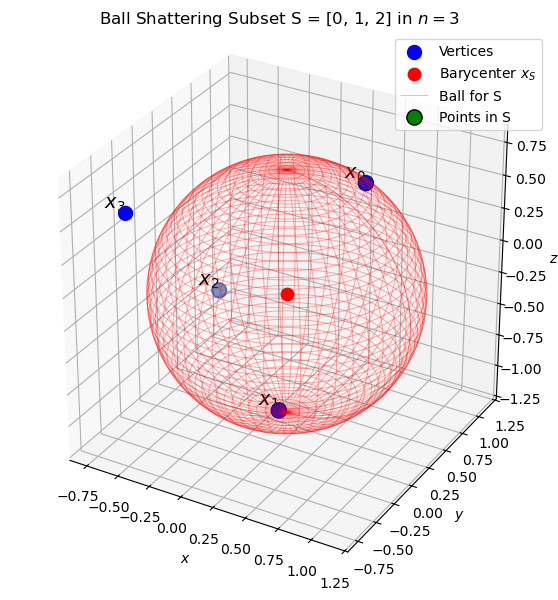

In [4]:
# Visualize shattering: pick a subset S and show the corresponding ball in 3D
# For demonstration, pick S = {0, 1, 2} (first three vertices)
S = [0, 1, 2]
S_vertices = vertices[S]

# Compute barycenter of S
x_S = S_vertices.mean(axis=0)

# Compute radius: distance from barycenter to any vertex in S
radius = np.linalg.norm(x_S - S_vertices[0])

# Plot in 3D
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color='blue', s=100, label='Vertices')
for i, v in enumerate(vertices):
    ax.text(v[0], v[1], v[2], f"$x_{{{i}}}$", fontsize=14, ha='right', va='bottom')
ax.scatter(x_S[0], x_S[1], x_S[2], color='red', s=80, label='Barycenter $x_S$')

# Draw the ball (as a wireframe sphere)
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = x_S[0] + radius * np.outer(np.cos(u), np.sin(v))
y = x_S[1] + radius * np.outer(np.sin(u), np.sin(v))
z = x_S[2] + radius * np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(x, y, z, color='red', alpha=0.3, linewidth=0.7, label='Ball for S')

# Highlight points in S
ax.scatter(S_vertices[:, 0], S_vertices[:, 1], S_vertices[:, 2], color='green', s=120, edgecolor='black', label='Points in S')

ax.set_box_aspect([1,1,1])
ax.set_title(f"Ball Shattering Subset S = {S} in $n={n}$")
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')
ax.legend()
plt.show()

## Explanation

The plot above shows the vertices of a regular simplex in $\mathbb{R}^2$ (an equilateral triangle). For a chosen subset $S$ of the vertices (here, $S = \{0, 1\}$), we compute the barycenter $x_S$ and draw the ball centered at $x_S$ with radius equal to the distance to any vertex in $S$.

This ball contains exactly the points in $S$ and excludes the others. Since this works for any subset $S$, the set of vertices is shattered by balls, demonstrating that the VC-dimension of balls in $\mathbb{R}^n$ is at least $n+1$.

Vertices of the regular tetrahedron:
x_0 = [-2.77555756e-17 -8.66025404e-01  5.55111512e-17]
x_1 = [-0.76273363  0.28867513  0.29138305]
x_2 = [0.63371194 0.28867513 0.51485517]
x_3 = [ 0.12902169  0.28867513 -0.80623822]

Pairwise distances:
||x_0 - x_1|| = 1.414214
||x_0 - x_2|| = 1.414214
||x_0 - x_3|| = 1.414214
||x_1 - x_2|| = 1.414214
||x_1 - x_3|| = 1.414214
||x_2 - x_3|| = 1.414214


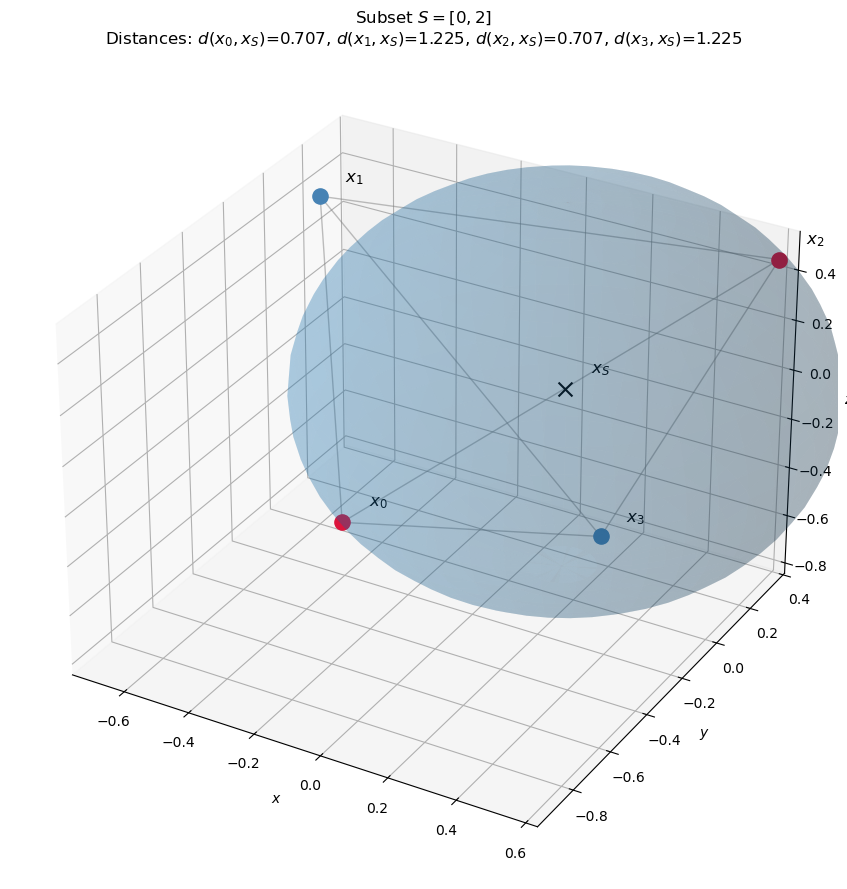

In [5]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# 1. Construct a regular 3-simplex (tetrahedron) in R^3
#    using 4 points in R^4 projected to the hyperplane sum x_i = 0
# ============================================================

def regular_simplex_3d():
    """
    Returns 4 vertices of a regular tetrahedron in R^3
    with all pairwise distances equal.
    """
    # Standard basis in R^4
    e = np.eye(4)

    # Subtract barycenter to lie in hyperplane sum x_i = 0
    ones = np.ones((4, 4)) / 4
    verts4 = e - ones[0]

    # Find an orthonormal basis of the 3D hyperplane sum x_i = 0
    # via SVD
    U, S, Vt = np.linalg.svd(verts4.T, full_matrices=False)
    basis = U[:, :3]  # 4x3 basis for the hyperplane

    # Project 4D points into 3D coordinates
    verts3 = verts4 @ basis

    return verts3


# ============================================================
# 2. Barycenter and separating ball for subset S
# ============================================================

def barycenter(points, subset):
    """Compute barycenter of points indexed by subset."""
    return np.mean(points[list(subset)], axis=0)


def separating_ball(points, subset):
    """
    For a nonempty subset S, returns:
      center = x_S
      radius = max distance from center to points in S
    By the simplex argument, this contains exactly the points in S.
    """
    center = barycenter(points, subset)
    inside_dists = [np.linalg.norm(points[i] - center) for i in subset]
    radius = max(inside_dists) if inside_dists else 0.0
    return center, radius


# ============================================================
# 3. Visualization
# ============================================================

def plot_subset_ball(points, subset, ax=None, show_labels=True):
    """
    Plot tetrahedron vertices and the ball that captures exactly subset.
    """
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')

    n_points = len(points)
    subset = set(subset)

    # Plot edges of tetrahedron
    for i, j in itertools.combinations(range(n_points), 2):
        xs = [points[i, 0], points[j, 0]]
        ys = [points[i, 1], points[j, 1]]
        zs = [points[i, 2], points[j, 2]]
        ax.plot(xs, ys, zs, color='gray', alpha=0.5, linewidth=1)

    # Plot vertices
    for i, p in enumerate(points):
        if i in subset:
            ax.scatter(*p, s=120, color='crimson')
        else:
            ax.scatter(*p, s=120, color='steelblue')

        if show_labels:
            ax.text(*(p + 0.05), f"$x_{i}$", fontsize=12)

    # Empty set: no ball needed
    if len(subset) == 0:
        ax.set_title("Subset $S = \\varnothing$ (empty set)")
        set_equal_axes(ax, points)
        return ax

    # Compute center and radius
    center, radius = separating_ball(points, subset)

    # Plot center
    ax.scatter(*center, s=100, color='black', marker='x')
    ax.text(*(center + 0.05), "$x_S$", fontsize=12, color='black')

    # Draw transparent sphere
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 25)
    xs = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    ys = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    zs = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(xs, ys, zs, alpha=0.2, linewidth=0)

    # Verify distances
    dists = [np.linalg.norm(points[i] - center) for i in range(len(points))]
    title = f"Subset $S = {sorted(subset)}$\nDistances: " + ", ".join(
        [f"$d(x_{i},x_S)$={dists[i]:.3f}" for i in range(len(points))]
    )
    ax.set_title(title)

    set_equal_axes(ax, np.vstack([points, center]))
    return ax


def set_equal_axes(ax, points):
    """
    Make 3D plot axes have equal scale.
    """
    x_vals = points[:, 0]
    y_vals = points[:, 1]
    z_vals = points[:, 2]

    x_mid = (x_vals.max() + x_vals.min()) / 2
    y_mid = (y_vals.max() + y_vals.min()) / 2
    z_mid = (z_vals.max() + z_vals.min()) / 2

    max_range = max(
        x_vals.max() - x_vals.min(),
        y_vals.max() - y_vals.min(),
        z_vals.max() - z_vals.min()
    ) / 2

    ax.set_xlim(x_mid - max_range, x_mid + max_range)
    ax.set_ylim(y_mid - max_range, y_mid + max_range)
    ax.set_zlim(z_mid - max_range, z_mid + max_range)

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_zlabel("$z$")


# ============================================================
# 4. Main demo
# ============================================================

if __name__ == "__main__":
    points = regular_simplex_3d()

    print("Vertices of the regular tetrahedron:")
    for i, p in enumerate(points):
        print(f"x_{i} = {p}")

    print("\nPairwise distances:")
    for i, j in itertools.combinations(range(4), 2):
        print(f"||x_{i} - x_{j}|| = {np.linalg.norm(points[i] - points[j]):.6f}")

    # --------------------------------------------------------
    # Choose which subset S to visualize:
    # Examples:
    #   S = {0}
    #   S = {0,2}
    #   S = {1,2,3}
    #   S = {0,1,2,3}
    # --------------------------------------------------------
    S = {0, 2}

    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection='3d')
    plot_subset_ball(points, S, ax=ax)
    plt.tight_layout()
    plt.show()